#**TP1: Análisis y Preparación de Datos Dataset de Diabetes**

## Integrantes:
  * Grioni, Agustín.
  * Lauritto, Irina.
  * Zaragoza, Guillermina.

## Objetivo:
En esta actividad se trabajará con un conjunto de datos médicos relacionado con el diagnóstico de diabetes. El objetivo es analizar el dataset, comprender su estructura y proponer una estrategia adecuada de preparación de datos para su posterior uso en modelos de aprendizaje automático.
El fin de la actividad es comprender los datos y prepararlos correctamente, no entrenar un modelo.

### Descripción del conjunto de datos
El dataset a utilizar proviene del National Institute of Diabetes and Digestive and Kidney Diseases. Su objetivo es predecir si un paciente tiene diabetes o no a partir de distintas mediciones clínicas. El archivo “diabetes.csv” se encuentra guardado en la carpeta “1_datos”.
El conjunto de datos contiene información de pacientes con las siguientes características:

*   Todas las pacientes son mujeres de al menos 21 años.
*   Todas pertenecen a la población Pima Indian.

Cada fila del dataset representa una paciente y cada columna representa una variable clínica medida.
Entre las variables disponibles se incluyen:
* número de embarazos,
* nivel de glucosa en sangre,
* presión arterial,
* grosor del pliegue cutáneo,
* nivel de insulina,
* índice de masa corporal (BMI),
* función genética asociada a diabetes,
* edad.

Además, el dataset contiene una variable llamada Outcome, que indica:

    1 → paciente con diabetes
    0 → paciente sin diabetes
Esta variable será considerada la variable objetivo (target).


El entorno de Google Colab utiliza sistemas de archivos efímeros que se liberan tras la finalización de la sesión del usuario o tras periodos de inactividad. La carga manual de archivos locales es ineficiente para flujos de trabajo reproducibles. El uso de un repositorio remoto garantiza la persistencia, disponibilidad y trazabilidad de los datos. Esta metodología permite que el análisis sea replicable por cualquier nodo sin necesidad de transferencias manuales de archivos, asegurando la integridad del pipeline de datos desde la fuente hasta el procesamiento.

In [39]:
!git clone https://github.com/AgustinG178/IA_2026.git
%cd IA_2026
!ls

Cloning into 'IA_2026'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 12 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 14.64 KiB | 2.44 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/IA_2026/IA_2026
diabetes.csv  README.md


In [40]:
# Se importan las librerías a utilizar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#**Actividad 1**

## Comprensión inicial del dataset
Cargue el dataset y observe las primeras filas. Determine:
* número de instancias,
* número de atributos,
* qué representa cada fila,
* qué representa cada columna.


Indique qué tipo de problema de aprendizaje automático representa este dataset: clasificación o regresión

In [61]:
# Se carga del dataset
dataset_diabetes = pd.read_csv("../1_datos/diabetes.csv")
header = dataset_diabetes.head()
dataset_diabetes.head()


FileNotFoundError: [Errno 2] No such file or directory: '../1_datos/diabetes.csv'

In [42]:
#Se levantan los parámetros del archivo utilizando la funcion "info" de la libreria pandas
dataset_diabetes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             767 non-null    float64
 3   SkinThickness             756 non-null    float64
 4   Insulin                   763 non-null    float64
 5   BMI                       767 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(5), int64(4)
memory usage: 60.0 KB


El dataset posee 8 atributos, entre los que se encuentran el número de embarazos, los niveles de glucosa, la presión arterial, el espesor de la piel, los niveles de insulina, el indice de masa corporal (BMI por sus siglas en inglés), un indicador de la posibilidad de heredar diabetes (*DiabetesPedigreeFunction*) y la edad de la paciente.
Hay en total 768 instancias en el archivo. <p>

Cada fila representa una instancia. Por otro lado, cada columna representa un atributo. Además existe una columna destinada al outcome o etiqueta de nuestro sistema.<p>

Debido a que se busca identificar para cada instancia si la paciente tiene diabetes (1) o no (0), el problema de aprendizaje automático que se presenta es de **clasificación**.


#**Actividad 2**
## Exploración inicial de los datos.

Realice una exploración del dataset. A partir de este análisis responda:
¿Qué tipos de datos aparecen?
¿Existen valores faltantes?
¿Existen variables con distribuciones sesgadas?
¿Existen variables con escalas muy diferentes?
Discuta brevemente sus observaciones.

Como se vió anteriormente en todos los casos los tipos de datos son numéricos. En algunos casos estos son enteros, por ejemplo en la edad, mientrras que en otros casos son flotantes, como para el BMI.


Si bien se observa que el total de instancias es de 768, para **blood presure** y **BMI** falta un dato, para **skin thickness** faltan doce y para **insulin** faltan cinco.

In [43]:
# Con la función describe se generan la estadística descriptiva del dataset
dataset_diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,767.000000,756.000000,763.000000,767.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.195567,20.862434,80.322412,32.034289,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.206609,15.865314,115.439459,7.804050,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,63.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,36.000000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,128.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


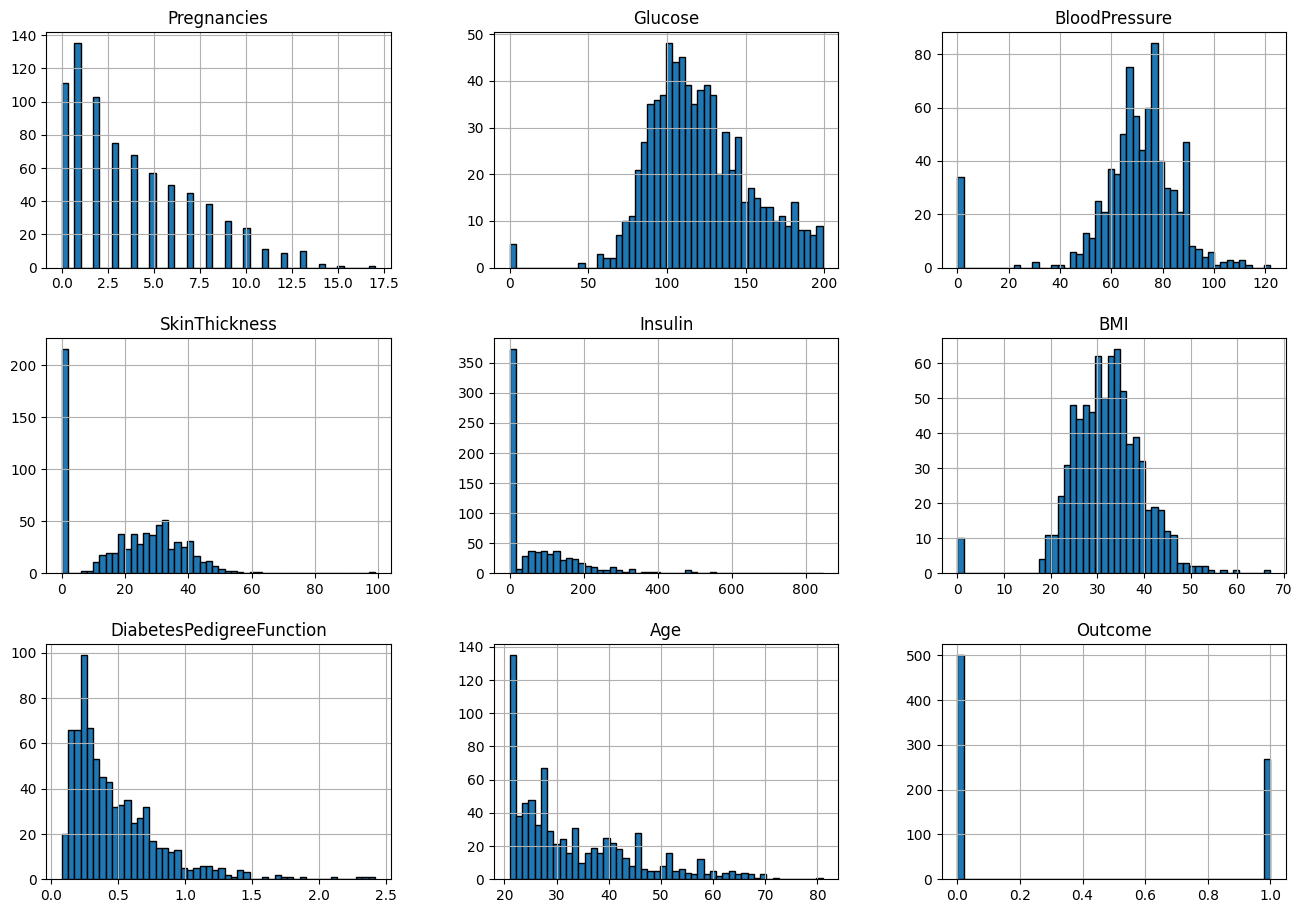

In [44]:
dataset_diabetes.hist(bins=50, edgecolor='k', figsize=(16,11))
plt.show()

Analizando los datos se puede notar que la mayoría de las variables presentan una distribución con asimetría positiva (cola larga extendida hacia la derecha, con la mayoría de los datos concentrados en el lado izquierdo), especialmente *Insulin*, *Age* y *DiabetesPedigreeFunction*. Esto refuerza el uso de la mediana para una futura imputación, ya que es menos sensible a los valores extremos que la media.

Por otro lado se observan variables con escalas muy diferentes,  como *Pregnancies* oscilan entre $0$ y $17$, mientras que *Insulin* llega hasta $846$. En próximas etapas será necesario un escalado (como MinMaxScaler) para que el modelo no asigne pesos erróneos.
<p>


# **Actividad 3**

## Análisis de posibles problemas en los datos

Algunos atributos médicos no pueden tomar el valor 0 en condiciones reales (por ejemplo, presión arterial o índice de masa corporal). *Identifique qué variables podrían contener valores inválidos o inconsistentes. Explique por qué estos valores podrían considerarse datos faltantes o errores de medición y proponga una estrategia para tratarlos.*

*Ojo!! Las distribuciones de ciertos atributos pueden diferir significativamente entre pacientes con y sin diabetes.*
*Discuta si sería apropiado imputar los valores faltantes utilizando una única media o mediana global, o si sería preferible utilizar una estrategia de imputación condicionada por la clase. Analice también las implicancias metodológicas de esta decisión.*

<p align="justify">
Tras el análisis descriptivo y la visualización de histogramas, se detectó una frecuencia anómala de valores iguales a cero en variables clínicas críticas como Insulin, Glucose, BloodPressure, SkinThickness y BMI.

<p align="justify">Desde la perspectiva de la fisiología humana, niveles de insulina, glucosa o presión arterial sistólica iguales a 0 son incompatibles con la vida. Por lo tanto, estos registros no representan valores reales, sino que deben interpretarse como datos faltantes (Missing Values) originados por errores en la recolección, fallas en los sensores de medición o falta de pruebas específicas.<p>

<p align="justify">Dado el volumen ocupado por los missing values, la eliminación de las instancias (filas) que contienen estos ceros resultaría en una pérdida de información crítica y un sesgo potencial en el modelo. Se propone la imputación de datos para mantener el volumen de información.<p>

<p align="justify">En datasets médicos es común que la distribución de ciertos atributos difiera significativamente entre pacientes con y sin la enfermedad. En el caso de la diabetes, variables como glucosa e insulina están directamente asociadas al diagnóstico, por lo que es esperable que sus distribuciones sean distintas entre pacientes diabéticos (Outcome = 1) y no diabéticos (Outcome = 0).<p>

<p align="justify"> Si se utilizara una imputación global (por ejemplo, la media o mediana calculada sobre todos los pacientes), se asumiría implícitamente que la distribución de estos atributos es homogénea en toda la población. Sin embargo, esto puede generar un  suavizado  de las diferencias entre clases, ya que los valores imputados quedarían en una zona intermedia entre ambas distribuciones. Como consecuencia, el modelo podría perder información relevante para distinguir entre pacientes con y sin diabetes.<p>

Por este motivo, resulta más apropiado aplicar una **imputación condicionada por clase**, calculando el estadístico (media o mediana) dentro de cada grupo definido por la variable objetivo (Outcome). De esta manera, los valores imputados respetan mejor las características fisiológicas propias de cada grupo y se preservan las diferencias estructurales que el modelo debe aprender.

<p align="justify">
No obstante, hay que tener ciertas precauciones porque la imputación basada en la variable objetivo introduce información de la clase en el proceso de preprocesamiento, lo que puede generar data leakage si no se implementa correctamente. Para evitar este problema, la imputación debe realizarse únicamente con los datos de entrenamiento dentro de cada partición del modelo (por ejemplo, en cada fold de validación cruzada), y luego aplicarse al conjunto de prueba. De lo contrario, se estaría incorporando indirectamente información del conjunto de test durante el entrenamiento.
<p>

#**Actividad 4**
## Representatividad de los datos
*Analice la distribución de la variable Outcome en el dataset y responda:
¿Las clases están balanceadas o desbalanceadas?*

Se analizan los datos para poder dar respuesta a esta pregunta.

In [45]:
# Contar pacientes por clase
conteo = dataset_diabetes["Outcome"].value_counts()

# Calcular porcentajes
porcentaje = dataset_diabetes["Outcome"].value_counts(normalize=True) * 100

print("Cantidad de pacientes:")
print(conteo)

print("\nPorcentaje de pacientes:")
print(porcentaje)

Cantidad de pacientes:
Outcome
0    500
1    268
Name: count, dtype: int64

Porcentaje de pacientes:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


Se observa que aproximadamente el 65% de los pacientes no presenta diabetes, mientras que alrededor del 35% sí la presenta.

Esto indica que las clases no están perfectamente balanceadas, ya que la cantidad de pacientes sin diabetes es considerablemente mayor que la de pacientes con la enfermedad. Sin embargo, el desbalance no es extremo, por lo que el dataset sigue siendo utilizable para tareas de clasificación.

Este tipo de desbalance moderado puede influir en el entrenamiento de modelos de aprendizaje automático, ya que algunos algoritmos podrían tender a predecir con mayor frecuencia la clase mayoritaria.

#**Actividad 5**

##División del dataset en conjunto de entrenamiento y conjunto de prueba

Dada la disponibilidad limitada de registros, se eligirá una proporcion 80/20 entre los datos para entrenamiento y para testeo. Esta proporción equilibra la necesidad de un entrenamiento robusto con una validación final confiable. Es imperativo realizar esta división antes de cualquier proceso de imputación de datos.

Si se calculase la media (o mediana) utilizando la totalidad del dataset antes de la partición, se estarían introduciendo información del conjunto de prueba en el entrenamiento. Esto se conoce como Data Leakage, lo cual invalidaría la evaluación del modelo al sesgar los resultados de forma optimista.

In [46]:
from sklearn.model_selection import train_test_split

X = dataset_diabetes.drop(columns=['Outcome'])
y = dataset_diabetes['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [47]:
X.value_counts()

Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI   DiabetesPedigreeFunction  Age
17           163      72.0           41.0           114.0    40.9  0.817                     47     1
0            57       60.0           0.0            0.0      21.7  0.735                     67     1
             67       76.0           0.0            0.0      45.3  0.194                     46     1
             73       0.0            0.0            0.0      21.1  0.342                     25     1
12           140      82.0           43.0           325.0    39.2  0.528                     58     1
                                                                                                   ..
0            91       68.0           32.0           210.0    39.9  0.381                     25     1
             86       68.0           32.0           0.0      35.8  0.238                     25     1
             84       82.0           31.0           125.0    38.2  0.233                     23     1
                      64.0           22.0           66.0     35.8  0.545                     21     1
             78       88.0           29.0           40.0     36.9  0.434                     21     1
Name: count, Length: 756, dtype: int64

In [48]:
y.value_counts()

,count
Outcome,
0,500
1,268


El dataset presenta un desbalance moderado (aproximadamente $65\%$ sanos vs $35\%$ diabéticos). Es fundamental reconocer este desbalance, ya que influye en la elección de la métrica de desempeño

Por este motivo, en la partición de datos se utilizó el parámetro stratify=y, garantizando que la proporción de la patología sea idéntica en el entrenamiento y en el testeo, evitando sesgos de selección.

# **Imputacion**

Se optará por una imputación condicionada por clase. Dado que la glucemia y la insulina son indicadores directos de la diabetes, un valor faltante en un paciente diabético (Outcome=1) debería imputarse con el estadístico de su propio grupo. Usar una media global "contaminaría" los datos, suavizando las diferencias fisiológicas que el modelo debe aprender a distinguir.

In [49]:
X_train_before = X_train.copy()                         # Guardamos los datos antes de imputar
null_rows_idx = X_train_before.isnull().any(axis=1)     # Detectamos las filas con valores faltantes
X_train_before[null_rows_idx]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
33,6,92,92.0,NaN,0.0,19.9,0.188,28
9,8,125,96.0,NaN,NaN,NaN,0.232,54
26,7,147,76.0,NaN,0.0,39.4,0.257,43
21,8,99,84.0,NaN,0.0,35.4,0.388,50
22,7,196,90.0,NaN,0.0,39.8,0.451,41
10,4,110,92.0,NaN,NaN,37.6,0.191,30
12,10,139,80.0,NaN,NaN,27.1,1.441,57
7,10,115,NaN,NaN,NaN,35.3,0.134,29
15,7,100,0.0,NaN,0.0,30.0,0.484,32
29,5,117,92.0,NaN,0.0,34.1,0.337,38


In [50]:
imputar = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

X_train[imputar] = X_train[imputar].replace(0, np.nan)
X_test[imputar] = X_test[imputar].replace(0, np.nan)

for col in imputar:
    medians = X_train.groupby(y_train)[col].median()

    X_train.loc[y_train == 0, col] = X_train.loc[y_train == 0, col].fillna(medians[0])

    X_train.loc[y_train == 1, col] = X_train.loc[y_train == 1, col].fillna(medians[1])

    X_test.loc[y_test == 0, col] = X_test.loc[y_test == 0, col].fillna(medians[0])

    X_test.loc[y_test == 1, col] = X_test.loc[y_test == 1, col].fillna(medians[1])

median_table = X_train.groupby(y_train)[imputar].median()
print(median_table)               # Tabla con las medianas para cada atributo
print('\n')

X_train[null_rows_idx]            # Observamos los valores después de imputar

         Glucose  BloodPressure  SkinThickness  Insulin    BMI
Outcome                                                       
0          108.0           70.0           27.0    100.0  30.10
1          141.5           76.0           33.0    168.0  34.35




,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
33,6,92.0,92.0,27.0,100.0,19.90,0.188,28
9,8,125.0,96.0,33.0,168.0,34.35,0.232,54
26,7,147.0,76.0,33.0,168.0,39.40,0.257,43
21,8,99.0,84.0,27.0,100.0,35.40,0.388,50
22,7,196.0,90.0,33.0,168.0,39.80,0.451,41
10,4,110.0,92.0,27.0,100.0,37.60,0.191,30
12,10,139.0,80.0,27.0,100.0,27.10,1.441,57
7,10,115.0,70.0,27.0,100.0,35.30,0.134,29
15,7,100.0,76.0,33.0,168.0,30.00,0.484,32
29,5,117.0,92.0,27.0,100.0,34.10,0.337,38


### Transformación de características

Cuando la distribución de una característica es muy sesgada, tanto el **escalado min-max** como la **estandarización** pueden no ser suficientes para mejorar el desempeño del modelo. Esto se debe a que ambos métodos tratan todos los valores de la misma manera, sin considerar la asimetría de la distribución.

En estos casos, antes de escalar un atributo, se recomienda transformarlo para reducir el sesgo y, si es posible, hacer que su distribución sea aproximadamente simétrica (normal o gaussiana). Esto puede mejorar la capacidad del modelo para capturar patrones en los datos.

Para características positivas con sesgo hacia la derecha, se puede aplicar una transformación de raíz cuadrada o elevarla a una potencia menor que 1 para comprimir los valores altos y expandir los valores pequeños.

Si la característica tiene una cola muy larga y pesada (es decir, valores muy grandes que afectan la distribución), se puede aplicar la **transformación logarítmica**


A partir de la visualización de los histogramas se observó que algunas variables presentan una distribución asimétrica hacia la derecha, especialmente *Insulin* y *DiabetesPedigreeFunction*. Estos atributos poseen colas largas con valores extremos que podrían afectar el desempeño de ciertos algoritmos de aprendizaje automático.

Para reducir este sesgo se aplicó una transformación logarítmica (log), la cual comprime los valores altos y genera distribuciones más cercanas a una forma simétrica.

Posteriormente, se aplica un proceso de estandarización mediante *StandardScaler* para normalizar las escalas de todas las variables antes del entrenamiento del modelo.

In [51]:
# Transformación logarítmica
log_cols = ['Insulin', 'DiabetesPedigreeFunction']

for col in log_cols:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

Se aplica un proceso de estandarización mediante *StandardScaler*. Esta técnica transforma cada variable restando su media y dividiéndola por su desviación estándar, generando variables con media cercana a cero y varianza unitaria. Esto permite que todas las características tengan una escala comparable y evita que aquellas con valores numéricos más grandes dominen el proceso de aprendizaje del modelo.

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

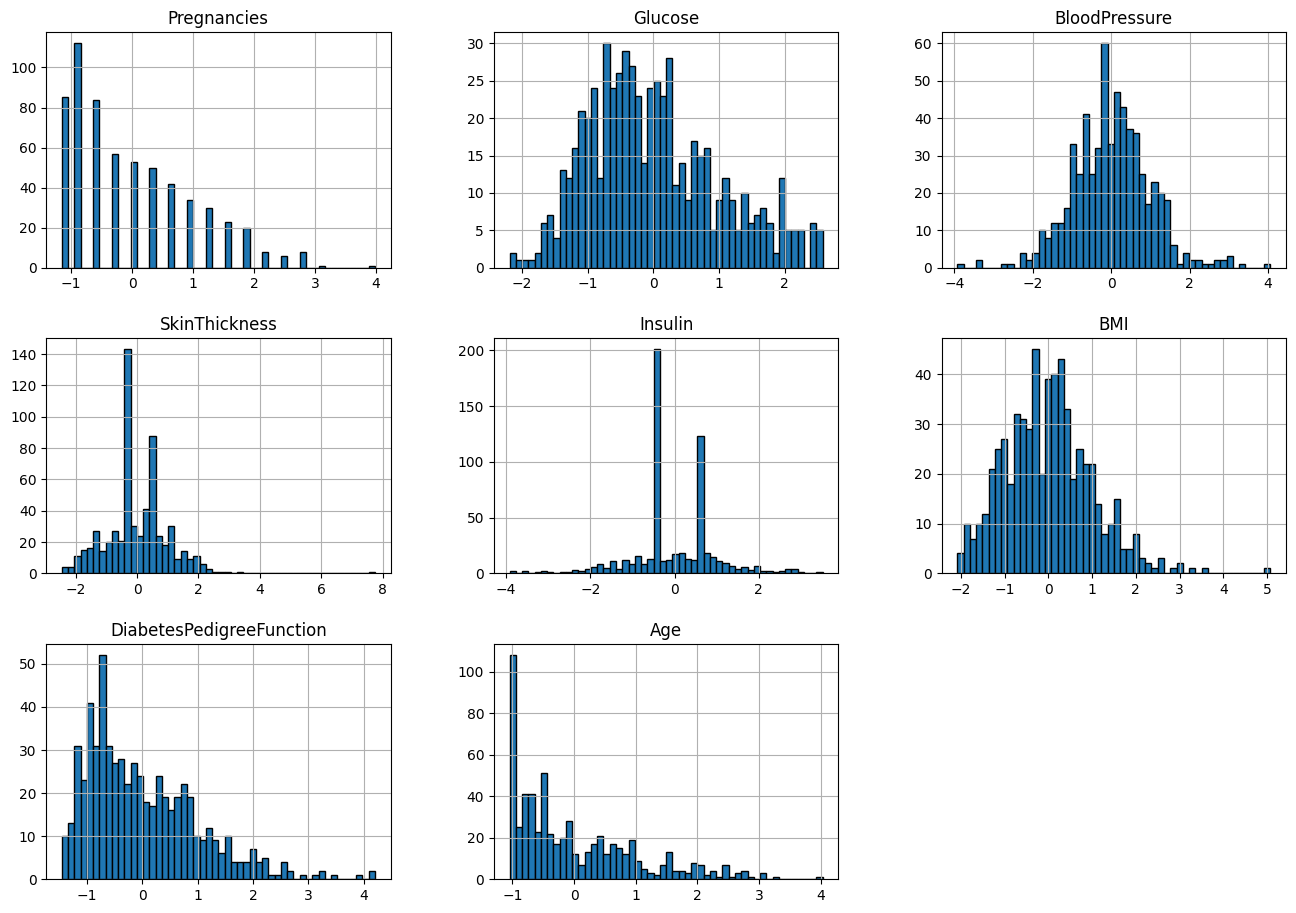

In [53]:
X_train_scaled.hist(bins=50, edgecolor='k', figsize=(16,11))
plt.show()

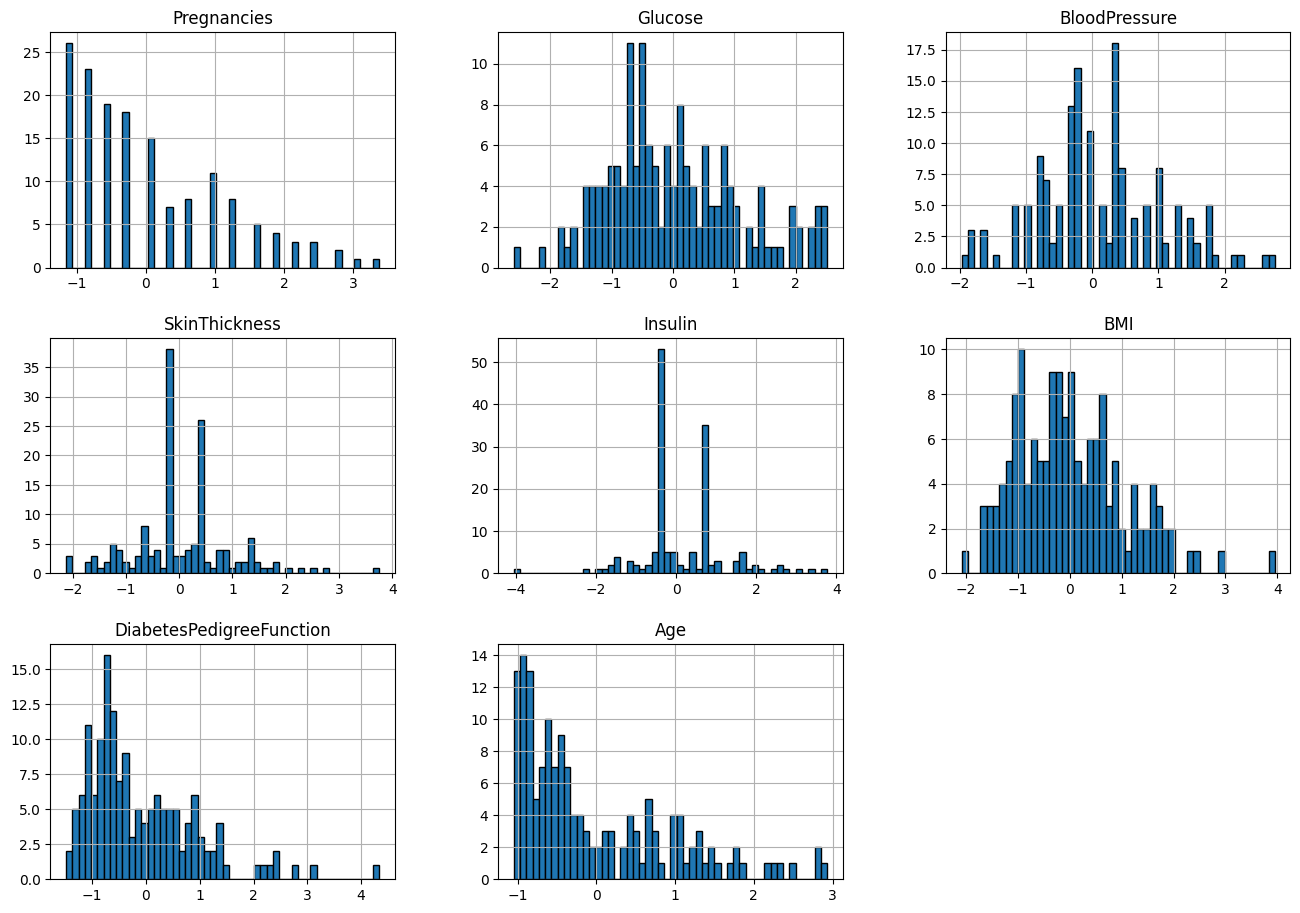

In [54]:
X_test_scaled.hist(bins=50, edgecolor='k', figsize=(16,11))
plt.show()

Como se explicó antes, todas las transformaciones de los datos, como imputación de valores faltantes y normalización, se ajustan utilizando únicamente el conjunto de entrenamiento. Posteriormente, estos mismos parámetros se aplican al conjunto de prueba.